## Import and installation

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os 
import re

In [8]:
import anndata as ad
import scanpy as sc
import mofapy2
import mofax
from mofapy2.run.entry_point import entry_point

In [9]:
from STalign import STalign

In [10]:
# Need to do once in the new container to deal with mofapy2 bug: one line of code is incompatibile with newer versions of pandas
#with new container need to change the fix, the path should be different
#read the file where error occurs
with open("/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py", "r") as f:
    content = f.read()
#print(content[3577:3693])
#make the fix
content_fixed = content.replace(
    content[3577:3693],
    "self.groupsidx = pd.factorize(np.array(self.group_labels))[0]"
)

#verify the replacement happened
assert content != content_fixed, "Replacement didn't happen - check the exact string"

#write back
with open("/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py", "w") as f:
    f.write(content_fixed)

print("Error is fixed")

FileNotFoundError: [Errno 2] No such file or directory: '/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py'

In [8]:
#fixed that was necessary to run code on several slices, need to recheck. Maybe something is still wrong. 
#have found also launching of mefisto on several slices, maybe will find the problem
path = "/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py"

with open(path, "r") as f:
    content = f.read()

old = """self.kronecker = np.all(
                [
                    np.all(
                        self.sample_cov_transformed[self.idx_inducing][
                            self.groupsidx == 0
                        ]
                        == self.sample_cov_transformed[self.idx_inducing][
                            self.groupsidx == g
                        ]
                    )
                    for g in range(self.G)
                ]
            )"""

new = """ref = self.sample_cov_transformed[self.idx_inducing][self.groupsidx == 0]
            self.kronecker = True
            for g in range(self.G):
                xg = self.sample_cov_transformed[self.idx_inducing][self.groupsidx == g]
                if ref.shape != xg.shape or not np.allclose(ref, xg, rtol=1e-6, atol=1e-8):
                    self.kronecker = False
                    break"""

assert old in content, "String not found - check exact whitespace in file"
content_fixed = content.replace(old, new)

with open(path, "w") as f:
    f.write(content_fixed)

print("Patched")

Patched


## Load data (old preprocessing code - used for the first experiments)

In [4]:
#function to load the data and combine many slices(but I will start with one slice)
def load_data(data_dir, file_names=None, all_files=False):
    if all_files:
        files_all = [f for f in os.listdir(data_dir) if f.endswith('.h5ad')]
    else:
        files_all = file_names
    if len(file_names)==1:
        combined_adata = sc.read_h5ad(os.path.join(data_dir, file_names[0]))
    else:
        adatas = {}
        for file in files_all:
            slice_name = file.replace('.h5ad', '')
            adata = sc.read_h5ad(os.path.join(data_dir, file))
            adata.obs_names = [f"{slice_name}_{x}" for x in adata.obs_names]
            adata.obs['slice'] = slice_name
            adatas[slice_name] = adata
            combined_adata = sc.concat(adatas.values(), label='slice', keys=list(adatas.keys()))

    #ensure spatial coordinates are in obsm['spatial']
    if 'spatial' not in combined_adata.obsm:
        combined_adata.obsm['spatial'] = combined_adata.obs[['x', 'y']].to_numpy()

    return combined_adata

In [5]:
data_dir="/home/jovyan/data/"
combined_adata=load_data(data_dir, file_names=["T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad"])

In [6]:
combined_adata

AnnData object with n_obs × n_vars = 19864 × 29828
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'

In [ ]:
data_dir="/home/jovyan/data/"
combined_adata2=load_data(data_dir, file_names=["T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"])

#compute percent_mt and qc metrics
combined_adata2.var["mt"] = combined_adata2.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(combined_adata2, qc_vars=["mt"], inplace=True)

# visual inspection
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(combined_adata2.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(combined_adata2.obs["total_counts"][combined_adata2.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.histplot(combined_adata2.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(combined_adata2.obs["n_genes_by_counts"][combined_adata2.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

#filtering of cells with too much counts or too high expression of mt genes,
#filtering of genes that are expressed in less than 10 cells
sc.pp.filter_cells(combined_adata2, min_counts=100)
#combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
sc.pp.filter_genes(combined_adata2, min_cells=1)

#save raw counts to a layer
combined_adata2.layers['counts'] = combined_adata2.X.copy()

#preprocesing
#calculate Pearson residuals
sc.experimental.pp.normalize_pearson_residuals(combined_adata2)

#save Pearson residuals to a layer
combined_adata2.layers['residuals'] = combined_adata2.X.copy()

def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

#find highly variable genes using Pearson residuals
pearson_highly_variable_genes(combined_adata2)

combined_adata2

## QC and preprocessing (also old code for preprocessing)

In [7]:
#compute percent_mt and qc metrics
combined_adata.var["mt"] = combined_adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(combined_adata, qc_vars=["mt"], inplace=True)

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

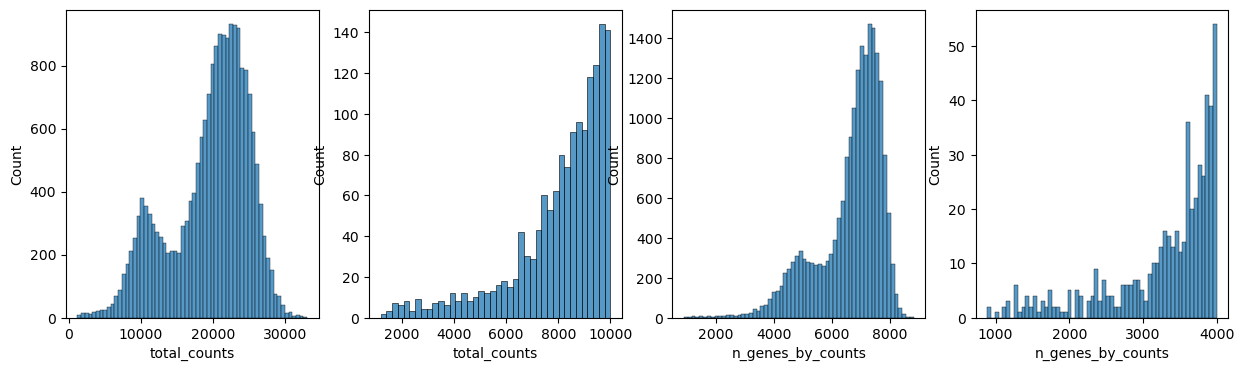

In [8]:
# visual inspection
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(combined_adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(combined_adata.obs["total_counts"][combined_adata.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.histplot(combined_adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(combined_adata.obs["n_genes_by_counts"][combined_adata.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

In [9]:
#filtering of cells with too much counts or too high expression of mt genes,
#filtering of genes that are expressed in less than 10 cells
sc.pp.filter_cells(combined_adata, min_counts=100)
#combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
sc.pp.filter_genes(combined_adata, min_cells=1)

In [10]:
#save raw counts to a layer
combined_adata.layers['counts'] = combined_adata.X.copy()

In [13]:
#preprocesing
#calculate Pearson residuals
sc.experimental.pp.normalize_pearson_residuals(combined_adata)

#save Pearson residuals to a layer
combined_adata.layers['residuals'] = combined_adata.X.copy()

def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

#find highly variable genes using Pearson residuals
pearson_highly_variable_genes(combined_adata)

In [ ]:
#if more than one slice:
#sc.experimental.pp.highly_variable_genes(
#    combined_adata,
#    flavor='pearson_residuals',
#    n_top_genes=2000,
#    batch_key='slice')
#combined_adata = combined_adata[:, combined_adata.var.highly_variable].copy()

In [14]:
combined_adata

AnnData object with n_obs × n_vars = 19864 × 29826
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'residual_variances', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

## MEFISTO 

### Info about the model:


-You cann specify groups, view and covariates
-There are many matrix operations, but the code is not optimized for gpu


#### Parameters:
ent.set_data_options(
    scale_views=False,
    scale_groups=False,
    center_groups=True,
    use_float32=False,
)

ent.set_data_from_anndata(
    adata,
    groups_label=None,
    use_raw=False,
    use_layer=None,
    likelihoods=None,
    features_subset=None,
    save_metadata=None,
)

ent.set_model_options(
    factors=10,
    spikeslab_factors=False,
    spikeslab_weights=True,
    ard_factors=False,
    ard_weights=True,
)

ent.set_train_options(
    iter=1000,
    startELBO=1,
    freqELBO=1,
    startSparsity=50,
    tolerance=None,
    convergence_mode='fast',
    startDrop=1,
    freqDrop=1,
    dropR2=None,
    nostop=False,
    verbose=False,
    quiet=False,
    seed=None,
    schedule=None,
    gpu_mode=False,
    gpu_device: Optional[int] = None,
    weight_views=False,
    outfile=None,
    save_interrupted=False,
)
ent.set_smooth_options(
    scale_cov=False,
    start_opt=20,
    n_grid=20,
    opt_freq=10,
    model_groups=True,
    warping=False,
    warping_freq=20,
    warping_ref=0,
    warping_open_begin=True,
    warping_open_end=True,
    sparseGP=False,
    frac_inducing=None,
    warping_groups=None,
)
#### Necessary params:
- scale_views=False - to scale view for unit variance(I already procesed data with pearson residiuls, so scale_views=False for me)
- use_float32=True to reduce memory and time
- scale_groups=False - ??
- center_groups=True - ??

-groups_label=None -??
- use_raw=False - use raw counts
- use_layer=None - use specific layer in adata
- likelihoods=None - ??
- features_subset=None  features_subset="highly_variable", use highly variable genes
- save_metadata=None - ??

- factors=10 - nemner of factors
- spikeslab_factors=False - ??
- spikeslab_weights=True - ??
- ard_factors=False - ??
- ard_weights=True - ??

- iter=1000 - maximum iteration that model will do
- startELBO=1 - ??
- freqELBO=1 - ??
- startSparsity=50 - ??
- tolerance=None - ??
- convergence_mode='fast' - ??
- startDrop=1 - ??
- freqDrop=1 - ??
- dropR2=None - ??
- nostop=False - ??
- verbose=False - ??
- quiet=False - ??
- seed=None - ??
- schedule=None - ??
- gpu_mode=False - ??
- gpu_device: Optional[int] = None - ??
- weight_views=False - ??
- outfile=None - ??
- save_interrupted=False  - ??

- scale_cov=False - ??
- start_opt=20 - ??
- n_grid=20 - ??
- opt_freq=10 - ??
- model_groups=True - ??
- warping=False - ??
- warping_freq=20 - ??
- warping_ref=0 - ??
- warping_open_begin=True - ??
- warping_open_end=True - ??
- sparseGP=False - use sparse Gaussian processes to speed up training
- frac_inducing=None - set proportion of spots used for inducing
- warping_groups=None - ??

#### To sum up, may try to vary:
- factors =3..20 (more factors longer training? Memory?)
- iter=100 ..1000
- May try convergence_mode='moderate' or 'slow' for more precise result
- And maybe consider save_interrupte=True to protect my results
- start_opt
- n_grid
- opt_freq 


In [33]:
#?ent.set_smooth_options

In [26]:
#??ent.set_covariates

### Experiment 1 

In [ ]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=4, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=10, sparseGP=True, frac_inducing=0.05, scale_cov=True,)
print("7 Ready")
print(ent.sample_cov.shape)

In [13]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [14]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -200319257.00 

Iteration 1: time=23.94, ELBO=-66530074.77, deltaELBO=133789182.230 (66.78797847%), Factors=4
Iteration 2: time=23.96, ELBO=-65847117.65, deltaELBO=682957.126 (0.34093433%), Factors=4
Iteration 3: time=24.14, ELBO=-65602149.65, deltaELBO=244967.993 (0.12228879%), Factors=4
Iteration 4: time=24.89, ELBO=-65473757.83, deltaELBO=128391.823 (0.06409360%), Factors=4
Iteration 5: time=25.24, ELBO=-65418310.71, deltaELBO=55447.122 (0.02767938%), Factors=4
Iteration 6: time=27.39, ELBO=-65395429.99, deltaELBO=22880.724 (0.01142213%), Factors=4
Iteration 7: time=26.43, ELBO=-65382446.16, deltaELBO=12983.823 (0.00648157%), Factors=4
Iteration 8: time=26.27, ELBO=-65374019.19, deltaELBO=8426.970 (0.00420677%), Factors=4
Iteration 9: time=25.97, ELBO=-65368292.80, deltaELBO=5726.393 (0.00285863%), Factors=4
Iteration 10: time=26.50, ELBO=-653

In [15]:
# 10. Save the model!
ent.save("ST_model1.hdf5")
print("10 Ready")

Saving model in ST_model1.hdf5...
10 Ready


### Experiment 2

In [30]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=4, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=10, sparseGP=True, frac_inducing=0.2, scale_cov=True,)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=19814 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [31]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [32]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -200325201.00 

Iteration 1: time=116.37, ELBO=-66536018.77, deltaELBO=133789182.230 (66.78599675%), Factors=4
Iteration 2: time=117.09, ELBO=-65853061.65, deltaELBO=682957.126 (0.34092422%), Factors=4
Iteration 3: time=121.23, ELBO=-65608093.65, deltaELBO=244967.993 (0.12228516%), Factors=4
Iteration 4: time=118.61, ELBO=-65479701.83, deltaELBO=128391.823 (0.06409170%), Factors=4
Iteration 5: time=121.81, ELBO=-65424254.71, deltaELBO=55447.122 (0.02767856%), Factors=4
Iteration 6: time=116.44, ELBO=-65401373.99, deltaELBO=22880.724 (0.01142179%), Factors=4
Iteration 7: time=108.79, ELBO=-65388390.16, deltaELBO=12983.823 (0.00648137%), Factors=4
Iteration 8: time=108.10, ELBO=-65379963.19, deltaELBO=8426.970 (0.00420664%), Factors=4
Iteration 9: time=116.12, ELBO=-65374236.80, deltaELBO=5726.393 (0.00285855%), Factors=4
Iteration 10: time=121.07,

In [34]:
# 10. Save the model!
ent.save("ST_model2.hdf5")
print("10 Ready")

Saving model in ST_model2.hdf5...
10 Ready


### Experiment 3

In [44]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=4, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.2, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=19814 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [45]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [46]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -200325201.00 

Iteration 1: time=114.51, ELBO=-66536018.77, deltaELBO=133789182.230 (66.78599675%), Factors=4
Iteration 2: time=112.76, ELBO=-65853061.65, deltaELBO=682957.126 (0.34092422%), Factors=4
Iteration 3: time=112.41, ELBO=-65608093.65, deltaELBO=244967.993 (0.12228516%), Factors=4
Iteration 4: time=108.83, ELBO=-65479701.83, deltaELBO=128391.823 (0.06409170%), Factors=4
Iteration 5: time=113.94, ELBO=-65424254.71, deltaELBO=55447.122 (0.02767856%), Factors=4
Iteration 6: time=114.35, ELBO=-65401373.99, deltaELBO=22880.724 (0.01142179%), Factors=4
Iteration 7: time=112.32, ELBO=-65388390.16, deltaELBO=12983.823 (0.00648137%), Factors=4
Iteration 8: time=112.36, ELBO=-65379963.19, deltaELBO=8426.970 (0.00420664%), Factors=4
Iteration 9: time=112.76, ELBO=-65374236.80, deltaELBO=5726.393 (0.00285855%), Factors=4
Iteration 10: time=111.67,

In [47]:
# 10. Save the model!
ent.save("ST_model3.hdf5")
print("10 Ready")

Saving model in ST_model3.hdf5...
10 Ready


### Experiment 4

Decided to optimize sigma node less often, because there was decrese in ELBO

In [13]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.2, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=19814 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [14]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [15]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -350426788.65 

Iteration 1: time=280.61, ELBO=-66653323.66, deltaELBO=283773464.991 (80.97938690%), Factors=10
Iteration 2: time=279.90, ELBO=-65678171.52, deltaELBO=975152.132 (0.27827557%), Factors=10
Iteration 3: time=274.33, ELBO=-65397754.36, deltaELBO=280417.159 (0.08002161%), Factors=10
Iteration 4: time=276.27, ELBO=-65312831.18, deltaELBO=84923.182 (0.02423422%), Factors=10
Iteration 5: time=287.49, ELBO=-65268177.90, deltaELBO=44653.285 (0.01274254%), Factors=10
Iteration 6: time=283.10, ELBO=-65243397.40, deltaELBO=24780.495 (0.00707152%), Factors=10
Iteration 7: time=289.96, ELBO=-65228582.21, deltaELBO=14815.196 (0.00422776%), Factors=10
Iteration 8: time=281.52, ELBO=-65219102.67, deltaELBO=9479.534 (0.00270514%), Factors=10
Iteration 9: time=281.95, ELBO=-65213172.30, deltaELBO=5930.374 (0.00169233%), Factors=10
Iteration 10: time

In [ ]:
# 10. Save the model!
ent.save("ST_model4.hdf5")
print("10 Ready")

Saving model in ST_model4.hdf5...


### Experiment 5

In [14]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=19814 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [15]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [16]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -350416883.65 

Iteration 1: time=146.05, ELBO=-66643418.66, deltaELBO=283773464.991 (80.98167589%), Factors=10
Iteration 2: time=141.09, ELBO=-65668266.52, deltaELBO=975152.132 (0.27828343%), Factors=10
Iteration 3: time=142.12, ELBO=-65387849.36, deltaELBO=280417.159 (0.08002387%), Factors=10
Iteration 4: time=140.99, ELBO=-65302926.18, deltaELBO=84923.182 (0.02423490%), Factors=10
Iteration 5: time=144.26, ELBO=-65258272.90, deltaELBO=44653.285 (0.01274290%), Factors=10
Iteration 6: time=142.51, ELBO=-65233492.40, deltaELBO=24780.495 (0.00707172%), Factors=10
Iteration 7: time=145.73, ELBO=-65218677.21, deltaELBO=14815.196 (0.00422788%), Factors=10
Iteration 8: time=139.89, ELBO=-65209197.67, deltaELBO=9479.534 (0.00270522%), Factors=10
Iteration 9: time=143.32, ELBO=-65203267.30, deltaELBO=5930.374 (0.00169238%), Factors=10
Iteration 10: time

In [ ]:
# 10. Save the model!
ent.save("ST_model5.hdf5")
print("10 Ready")

Saving model in ST_model5.hdf5...


### Experiment 6

In [20]:
t_all=np.array([146.05, 141.09, 142.12, 140.99, 144.26, 142.51, 145.73, 139.89, 143.32, 144.24, 143.90, 143.44, 140.70, 143.49, 143.05, 146.24, 139.94, 143.01, 144.44, 1516.91, 571.19, 565.04, 571.33, 569.87, 577.99, 570.44, 572.44, 573.39, 568.77, 563.60, 563.55, 571.19, 568.60, 579.42, 567.14, 570.09, 570.54, 571.25, 576.32, 1915.59, 572.58, 569.85, 566.10, 568.96, 568.60, 569.27, 565.75, 571.98, 572.04, 566.66, 573.64, 576.05, 569.09])

In [23]:
(t_all.sum()/60)/60

np.float64(6.778788888888888)

In [24]:
t_all2=np.array([280.61, 279.90, 274.33, 276.27, 287.49, 283.10, 289.96, 281.52, 281.95, 275.99, 278.01, 275.08, 275.67, 275.40, 272.44, 273.27, 269.97, 269.37, 268.36, 8086.91, 1656.23, 1658.23, 1658.99, 1659.76, 1657.43, 1868.49, 1989.44, 1987.97, 1997.54, 1983.71, 1990.48, 1991.59, 1999.96, 1965.07, 1969.90, 1974.50, 1972.40, 1975.29, 1987.73])

In [25]:
(t_all2.sum()/60)/60

np.float64(13.694530555555557)

In [15]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=19864 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [16]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


42 gb

In [17]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -352496047.94 

Iteration 1: time=41.01, ELBO=-67181548.31, deltaELBO=285314499.629 (80.94119106%), Factors=10
Iteration 2: time=42.98, ELBO=-66211263.86, deltaELBO=970284.452 (0.27526109%), Factors=10
Iteration 3: time=43.11, ELBO=-65935926.25, deltaELBO=275337.613 (0.07811084%), Factors=10
Iteration 4: time=39.10, ELBO=-65854186.95, deltaELBO=81739.297 (0.02318871%), Factors=10
Iteration 5: time=42.09, ELBO=-65810253.10, deltaELBO=43933.855 (0.01246364%), Factors=10
Iteration 6: time=38.76, ELBO=-65785462.82, deltaELBO=24790.278 (0.00703278%), Factors=10
Iteration 7: time=39.29, ELBO=-65770952.46, deltaELBO=14510.356 (0.00411646%), Factors=10
Iteration 8: time=40.61, ELBO=-65761743.44, deltaELBO=9209.027 (0.00261252%), Factors=10
Iteration 9: time=38.96, ELBO=-65755831.66, deltaELBO=5911.773 (0.00167712%), Factors=10
Iteration 10: time=41.34, E

During training ~49.7

In [18]:
# 10. Save the model!
ent.save("ST_model6.hdf5")
print("10 Ready")

Saving model in ST_model6.hdf5...
10 Ready


### Experiment 7: new slice

AnnData object with n_obs × n_vars = 20730 × 29780
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'residual_variances', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

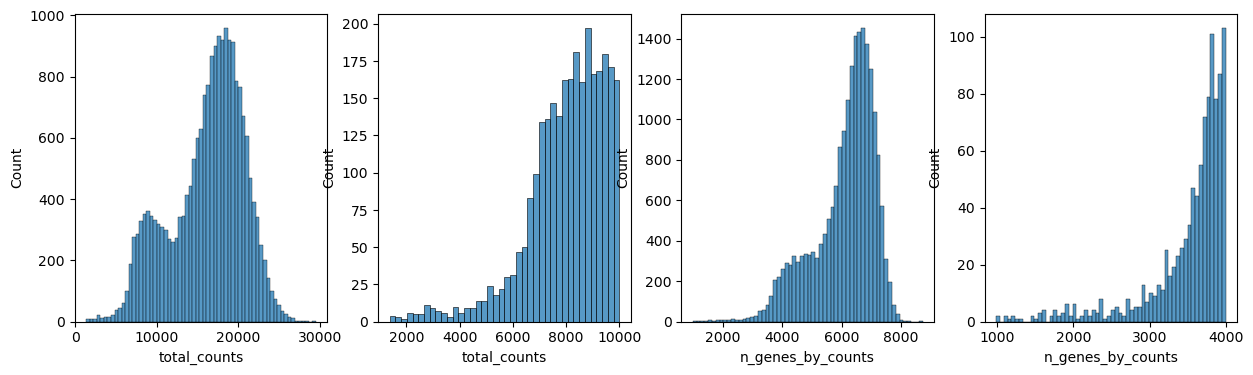

In [5]:
data_dir="/home/jovyan/data/"
combined_adata2=load_data(data_dir, file_names=["T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"])

#compute percent_mt and qc metrics
combined_adata2.var["mt"] = combined_adata2.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(combined_adata2, qc_vars=["mt"], inplace=True)

# visual inspection
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(combined_adata2.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(combined_adata2.obs["total_counts"][combined_adata2.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.histplot(combined_adata2.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(combined_adata2.obs["n_genes_by_counts"][combined_adata2.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

#filtering of cells with too much counts or too high expression of mt genes,
#filtering of genes that are expressed in less than 10 cells
sc.pp.filter_cells(combined_adata2, min_counts=100)
#combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
sc.pp.filter_genes(combined_adata2, min_cells=1)

#save raw counts to a layer
combined_adata2.layers['counts'] = combined_adata2.X.copy()

#preprocesing
#calculate Pearson residuals
sc.experimental.pp.normalize_pearson_residuals(combined_adata2)

#save Pearson residuals to a layer
combined_adata2.layers['residuals'] = combined_adata2.X.copy()

def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

#find highly variable genes using Pearson residuals
pearson_highly_variable_genes(combined_adata2)

combined_adata2

In [7]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata2, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata2.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=20730 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [8]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [9]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -348009324.22 

Iteration 1: time=64.19, ELBO=-69568646.96, deltaELBO=278440677.252 (80.00954511%), Factors=10
Iteration 2: time=56.07, ELBO=-68798010.74, deltaELBO=770636.227 (0.22144126%), Factors=10
Iteration 3: time=56.01, ELBO=-68598783.66, deltaELBO=199227.077 (0.05724763%), Factors=10
Iteration 4: time=47.07, ELBO=-68533752.86, deltaELBO=65030.803 (0.01868651%), Factors=10
Iteration 5: time=53.29, ELBO=-68509992.19, deltaELBO=23760.671 (0.00682760%), Factors=10
Iteration 6: time=47.69, ELBO=-68497779.34, deltaELBO=12212.845 (0.00350934%), Factors=10
Iteration 7: time=57.36, ELBO=-68490673.53, deltaELBO=7105.806 (0.00204184%), Factors=10
Iteration 8: time=46.30, ELBO=-68486393.77, deltaELBO=4279.766 (0.00122978%), Factors=10
Iteration 9: time=48.61, ELBO=-68483793.19, deltaELBO=2600.582 (0.00074727%), Factors=10
Iteration 10: time=50.81, EL

In [10]:
# 10. Save the model!
ent.save("ST_model7.hdf5")
print("10 Ready")

Saving model in ST_model7.hdf5...
10 Ready


### Experiment 10

AnnData object with n_obs × n_vars = 12761 × 29172
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'residual_variances', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

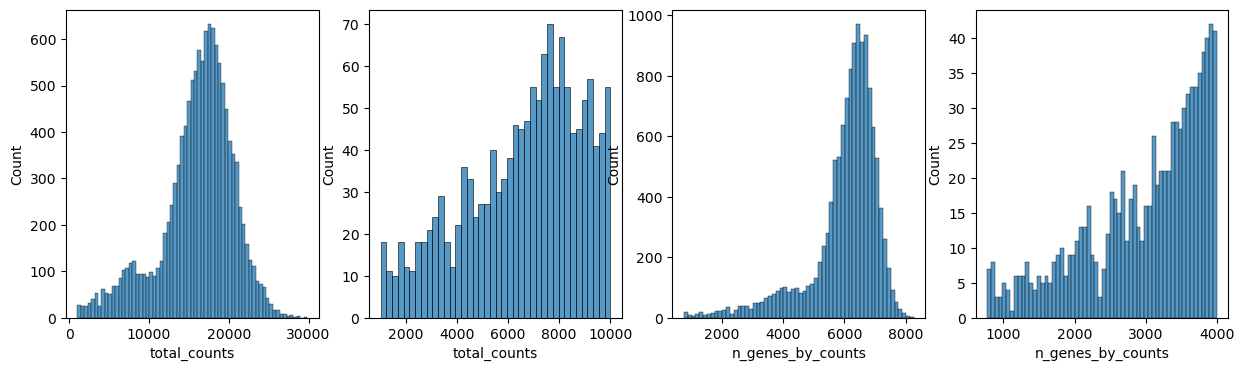

In [4]:
data_dir="/home/jovyan/data/"
combined_adata3=load_data(data_dir, file_names=["T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad"])

#compute percent_mt and qc metrics
combined_adata3.var["mt"] = combined_adata3.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(combined_adata3, qc_vars=["mt"], inplace=True)

# visual inspection
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(combined_adata3.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(combined_adata3.obs["total_counts"][combined_adata3.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.histplot(combined_adata3.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(combined_adata3.obs["n_genes_by_counts"][combined_adata3.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

#filtering of cells with too much counts or too high expression of mt genes,
#filtering of genes that are expressed in less than 10 cells
sc.pp.filter_cells(combined_adata3, min_counts=100)
#combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
sc.pp.filter_genes(combined_adata3, min_cells=1)

#save raw counts to a layer
combined_adata3.layers['counts'] = combined_adata3.X.copy()

#preprocesing
#calculate Pearson residuals
sc.experimental.pp.normalize_pearson_residuals(combined_adata3)

#save Pearson residuals to a layer
combined_adata3.layers['residuals'] = combined_adata3.X.copy()

def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

#find highly variable genes using Pearson residuals
pearson_highly_variable_genes(combined_adata3)

combined_adata3

In [5]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata3, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata3.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=12761 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [6]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [7]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -213074829.57 

Iteration 1: time=15.23, ELBO=-42990872.12, deltaELBO=170083957.455 (79.82358019%), Factors=10
Iteration 2: time=17.65, ELBO=-42533142.78, deltaELBO=457729.337 (0.21482093%), Factors=10
Iteration 3: time=18.50, ELBO=-42456928.77, deltaELBO=76214.014 (0.03576866%), Factors=10
Iteration 4: time=15.72, ELBO=-42426652.90, deltaELBO=30275.868 (0.01420903%), Factors=10
Iteration 5: time=19.87, ELBO=-42412881.58, deltaELBO=13771.322 (0.00646314%), Factors=10
Iteration 6: time=16.05, ELBO=-42404435.51, deltaELBO=8446.067 (0.00396390%), Factors=10
Iteration 7: time=16.52, ELBO=-42398668.93, deltaELBO=5766.580 (0.00270636%), Factors=10
Iteration 8: time=15.71, ELBO=-42394630.08, deltaELBO=4038.852 (0.00189551%), Factors=10
Iteration 9: time=16.55, ELBO=-42391719.19, deltaELBO=2910.887 (0.00136613%), Factors=10
Iteration 10: time=16.24, ELBO

In [8]:
# 10. Save the model!
ent.save("ST_model8.hdf5")
print("10 Ready")

Saving model in ST_model8.hdf5...
10 Ready


### Experiment 11

AnnData object with n_obs × n_vars = 15509 × 29302
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'residual_variances', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

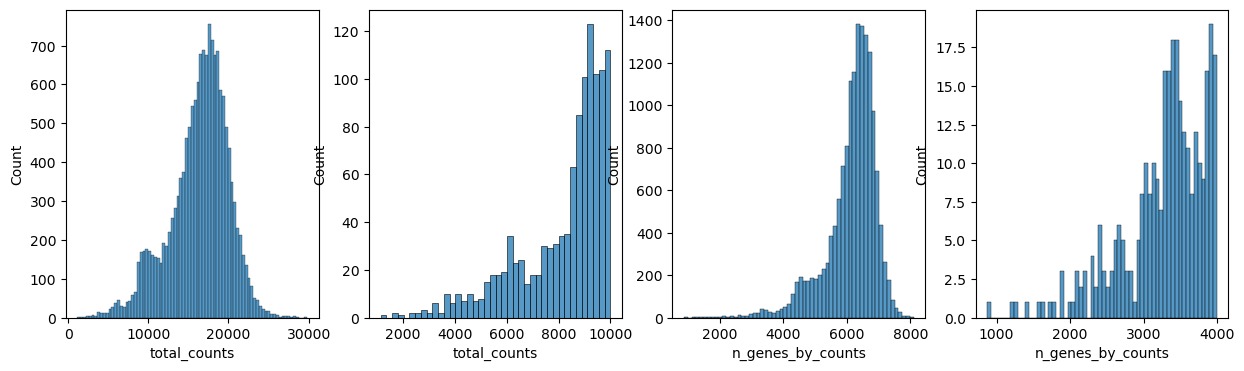

In [9]:
data_dir="/home/jovyan/data/"
combined_adata5=load_data(data_dir, file_names=["T1092_MT63_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad"])
#compute percent_mt and qc metrics
combined_adata5.var["mt"] = combined_adata5.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(combined_adata5, qc_vars=["mt"], inplace=True)

# visual inspection
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(combined_adata5.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(combined_adata5.obs["total_counts"][combined_adata5.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.histplot(combined_adata5.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(combined_adata5.obs["n_genes_by_counts"][combined_adata5.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

#filtering of cells with too much counts or too high expression of mt genes,
#filtering of genes that are expressed in less than 10 cells
sc.pp.filter_cells(combined_adata5, min_counts=100)
#combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
sc.pp.filter_genes(combined_adata5, min_cells=1)

#save raw counts to a layer
combined_adata5.layers['counts'] = combined_adata5.X.copy()

#preprocesing
#calculate Pearson residuals
sc.experimental.pp.normalize_pearson_residuals(combined_adata5)

#save Pearson residuals to a layer
combined_adata5.layers['residuals'] = combined_adata5.X.copy()

def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

#find highly variable genes using Pearson residuals
pearson_highly_variable_genes(combined_adata5)

combined_adata5

In [10]:
## ONE SLICE 
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(combined_adata5, use_layer="residuals", features_subset="highly_variable")
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
#Let's stick with the first option like in tutorial
ent.set_covariates([combined_adata5.obsm["spatial"]], covariates_names=["imagerow", "imagecol"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='group1' with N=15509 samples and D=2000 features...


3 Ready
Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
-

In [11]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [12]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -272346995.66 

Iteration 1: time=28.61, ELBO=-51572482.42, deltaELBO=220774513.232 (81.06368594%), Factors=10
Iteration 2: time=31.39, ELBO=-50899506.60, deltaELBO=672975.825 (0.24710235%), Factors=10
Iteration 3: time=25.41, ELBO=-50816702.09, deltaELBO=82804.511 (0.03040405%), Factors=10
Iteration 4: time=29.47, ELBO=-50778467.31, deltaELBO=38234.775 (0.01403899%), Factors=10
Iteration 5: time=25.96, ELBO=-50751665.57, deltaELBO=26801.746 (0.00984103%), Factors=10
Iteration 6: time=28.34, ELBO=-50734748.66, deltaELBO=16916.912 (0.00621153%), Factors=10
Iteration 7: time=24.24, ELBO=-50722585.61, deltaELBO=12163.047 (0.00446601%), Factors=10
Iteration 8: time=27.44, ELBO=-50711998.74, deltaELBO=10586.866 (0.00388727%), Factors=10
Iteration 9: time=24.26, ELBO=-50702832.28, deltaELBO=9166.466 (0.00336573%), Factors=10
Iteration 10: time=29.01, E

In [13]:
# 10. Save the model!
ent.save("ST_model9.hdf5")
print("10 Ready")

Saving model in ST_model9.hdf5...
10 Ready


### Experiment 12: several slices at once

In [5]:
# Load and preprocess each slice independently 
data_dir = "/home/jovyan/data/"
slice_files = [["T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad"], ["T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"]]

ads = []
for sl in slice_files:
    adata = load_data(data_dir, file_names=sl)
    
    # QC per slice
    adata.var["mt"] = adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    sc.pp.filter_cells(adata, min_counts=100)
    sc.pp.filter_genes(adata, min_cells=10)
    
    # Save raw counts before any normalization
    adata.layers['counts'] = adata.X.copy()
    
    ads.append(adata)

# Merge on gene intersection 
adata_merged = ad.concat(
    ads,
    label="batch",
    keys=["sample_1", "sample_2"],
    join="inner")

# HVG on raw counts, per batch 
sc.experimental.pp.highly_variable_genes(
    adata_merged,
    n_top_genes=2000,
    batch_key="batch",
    flavor="pearson_residuals",
    layer="counts"
)

# Pearson residuals on merged object 
sc.experimental.pp.normalize_pearson_residuals(adata_merged, layer="counts")
adata_merged.layers['residuals'] = adata_merged.X.copy()

# Sanity checks 
print("Total cells:", adata_merged.n_obs)
print("Total genes:", adata_merged.n_vars)
print("HVGs:", adata_merged.var['highly_variable'].sum())
print("Batch counts:\n", adata_merged.obs['batch'].value_counts())
print("Spatial coords shape:", adata_merged.obsm["spatial"].shape)

coords_s1 = adata_merged[adata_merged.obs["batch"] == "sample_1"].obsm["spatial"]
coords_s2 = adata_merged[adata_merged.obs["batch"] == "sample_2"].obsm["spatial"]
print("Slice 1 coord range x:", coords_s1[:, 0].min(), "—", coords_s1[:, 0].max())
print("Slice 2 coord range x:", coords_s2[:, 0].min(), "—", coords_s2[:, 0].max())

Total cells: 40594
Total genes: 27389
HVGs: 2000
Batch counts:
 batch
sample_2    20730
sample_1    19864
Name: count, dtype: int64
Spatial coords shape: (40594, 2)
Slice 1 coord range x: 1200 — 20100
Slice 2 coord range x: 1400 — 20200


In [6]:
adata_merged

AnnData object with n_obs × n_vars = 40594 × 27389
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts', 'batch'
    var: 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: 'hvg', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

In [7]:
layer = adata_merged.layers['residuals']
adata_merged.layers['residuals'] = layer.astype(np.float32)
print(adata_merged.layers['residuals'].dtype)

float32


In [8]:
## CORRECTY INITIALIZE MODEL ON SEVERAL SLICES(TBD)
# 1. Initialize the entry point
ent = entry_point()

print("1 Ready")
# 2. Set data options
ent.set_data_options(use_float32=True, scale_views=False)
print("2 Ready")

# 3. Pass the data to the model
ent.set_data_from_anndata(adata_merged, use_layer="residuals", groups_label="batch", features_subset="highly_variable", likelihoods=["gaussian"])
print("3 Ready")

# 4. Set model options
ent.set_model_options(factors=10, spikeslab_weights=True, ard_weights=True)
print("4 Ready")

# 5. Set training options
ent.set_train_options(seed=42, save_interrupted=True)
print("5 Ready")

# 6. Set covariates (here spatial)
coords_s1 = adata_merged[adata_merged.obs["batch"] == "sample_1"].obsm["spatial"]
coords_s2 = adata_merged[adata_merged.obs["batch"] == "sample_2"].obsm["spatial"]

ent.set_covariates([coords_s1, coords_s2],covariates_names=["x", "y"])
print(ent.sample_cov.shape)
print("6 Ready")

# 7. Set smooth options for MEFISTO
ent.set_smooth_options(start_opt=20, opt_freq=20, sparseGP=True, frac_inducing=0.1, scale_cov=True, model_groups=True)
print("7 Ready")
print(ent.sample_cov.shape)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


1 Ready
use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...

2 Ready
Loaded view='rna' group='sample_1' with N=19864 samples and D=2000 features...
Loaded view='rna' group='sample_2' with N=20730 samples and D=2000 features...


3 Ready

Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Deter

In [9]:
# 8. Build the model
ent.build()
print("8 Ready")

8 Ready


In [10]:
# 9. Run the model!
ent.run()
print("9 Ready")



######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -1068938510.28 

Iteration 1: time=232.94, ELBO=-56599283.10, deltaELBO=1012339227.183 (94.70509458%), Factors=10
Iteration 2: time=201.12, Factors=10
Iteration 3: time=206.88, Factors=10
Iteration 4: time=205.85, Factors=10
Iteration 5: time=202.79, Factors=10
Iteration 6: time=230.95, ELBO=-51233375.71, deltaELBO=5365907.382 (0.50198466%), Factors=10
Iteration 7: time=201.67, Factors=10
Iteration 8: time=200.46, Factors=10
Iteration 9: time=200.17, Factors=10
Iteration 10: time=201.43, Factors=10
Iteration 11: time=226.73, ELBO=-51114437.82, deltaELBO=118937.894 (0.01112673%), Factors=10
Iteration 12: time=198.90, Factors=10
Iteration 13: time=199.50, Factors=10
Iteration 14: time=197.84, Factors=10
Iteration 15: time=197.02, Factors=10
Iteration 16: time=231.20, ELBO=-51074700.10, deltaELBO=39737.724 (0.00371749%), Factors=10
Iteration 17: tim

The training was not finished, I interrupted it, because optimisation of the sigma node was running for too long

In [ ]:
# 10. Save the model!
ent.save("ST_model10.hdf5")
print("10 Ready")

## Results interpretation

### Model 1 

In [17]:
m = mofax.mofa_model("ST_model1.hdf5")

In [18]:
m

MOFA+ model: ST model1
Samples (cells): 19814
Features: 2000
Groups: group1 (19814)
Views: rna (2000)
Factors: 4
Expectations: Sigma, W, Z

MEFISTO:
Covariates available: imagerow, imagecol

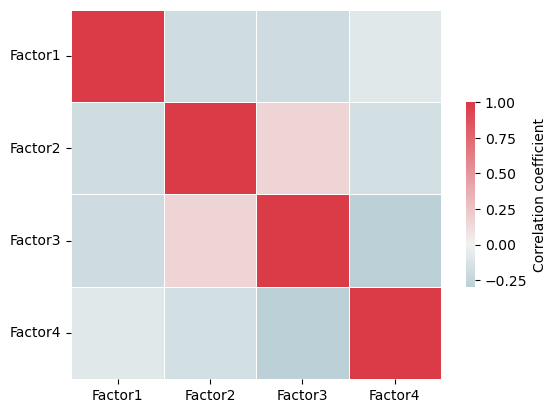

In [20]:
mofax.plot_factors_correlation(m);

In [21]:
combined_adata.obs = combined_adata.obs.join(m.get_factors(df=True))

In [22]:
combined_adata

AnnData object with n_obs × n_vars = 19814 × 27713
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_counts', 'Factor1', 'Factor2', 'Factor3', 'Factor4'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'residual_variances', 'highly_variable'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'pearson_residuals_normalization'
    obsm: 'spatial'
    layers: 'counts', 'residuals'

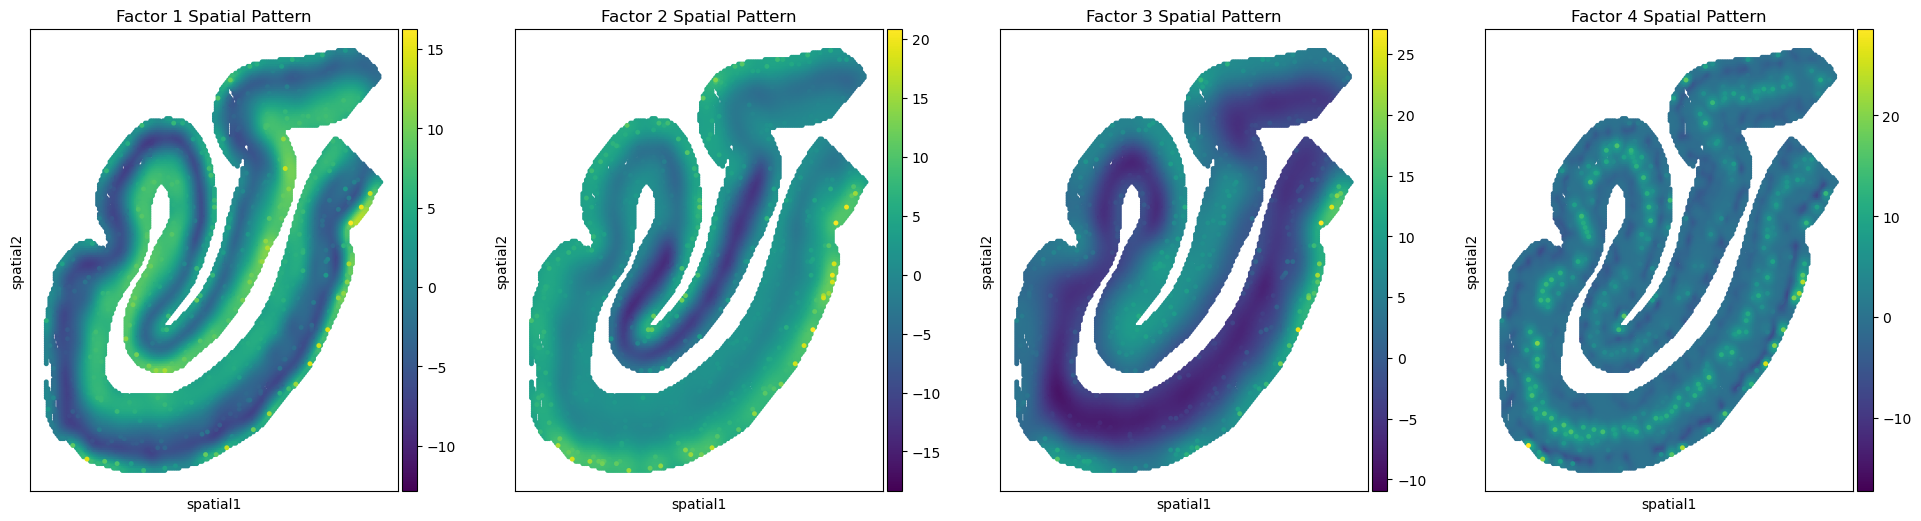

In [29]:
#plot spatial distribution of each factor
fig, ax = plt.subplots(1,4, figsize=(24, 6))
for factor_idx in range(1,5):
    sc.pl.embedding(
        combined_adata,
        basis='spatial',
        color=f'Factor{factor_idx}',
        size=50,
        color_map='viridis',
        show=False,
        ax=ax[factor_idx-1]
    )
    ax[factor_idx-1].set_title(f'Factor {factor_idx} Spatial Pattern')
plt.show()

### Model 3 

In [35]:
m = mofax.mofa_model("ST_model2.hdf5")

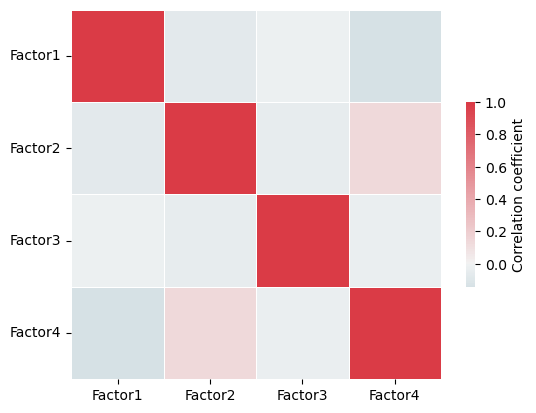

In [36]:
mofax.plot_factors_correlation(m);

In [39]:
factor_df=m.get_factors(df=True)

In [40]:
factor_df = factor_df.rename(columns={"Factor1": "Factor1_model2", "Factor2": "Factor2_model2","Factor3": "Factor3_model2", "Factor4": "Factor4_model2"})

In [42]:
combined_adata.obs = combined_adata.obs.join(factor_df)

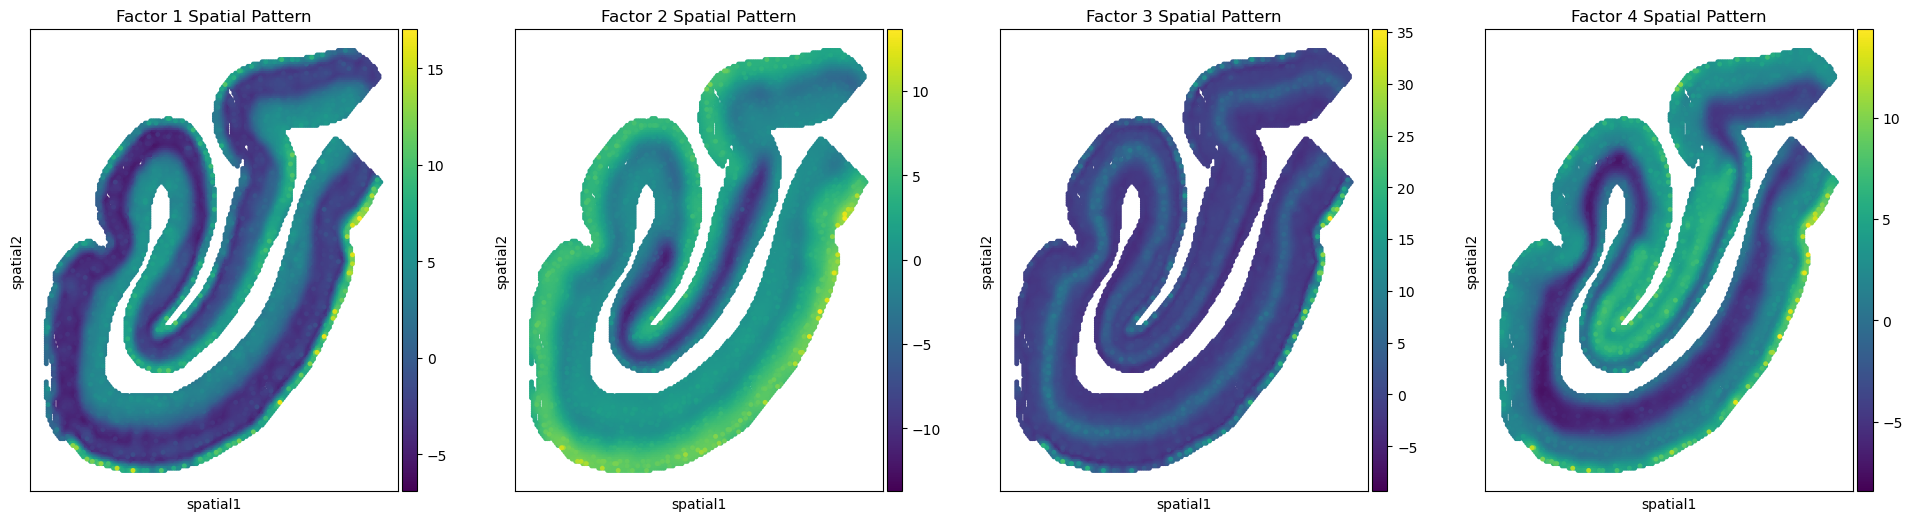

In [43]:
#plot spatial distribution of each factor
fig, ax = plt.subplots(1,4, figsize=(24, 6))
for factor_idx in range(1,5):
    sc.pl.embedding(
        combined_adata,
        basis='spatial',
        color=f'Factor{factor_idx}_model2',
        size=50,
        color_map='viridis',
        show=False,
        ax=ax[factor_idx-1]
    )
    ax[factor_idx-1].set_title(f'Factor {factor_idx} Spatial Pattern')
plt.show()

### Model 3

In [17]:
m = mofax.mofa_model("ST_model3.hdf5")

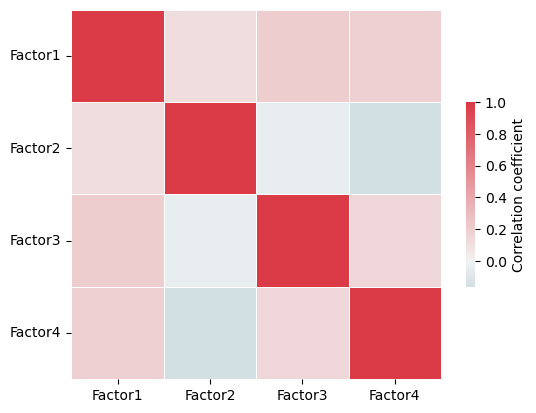

In [18]:
mofax.plot_factors_correlation(m);

In [19]:
factor_df=m.get_factors(df=True)

In [20]:
factor_df = factor_df.rename(columns={"Factor1": "Factor1_model3", "Factor2": "Factor2_model3","Factor3": "Factor3_model3", "Factor4": "Factor4_model3"})

In [21]:
combined_adata.obs = combined_adata.obs.join(factor_df)

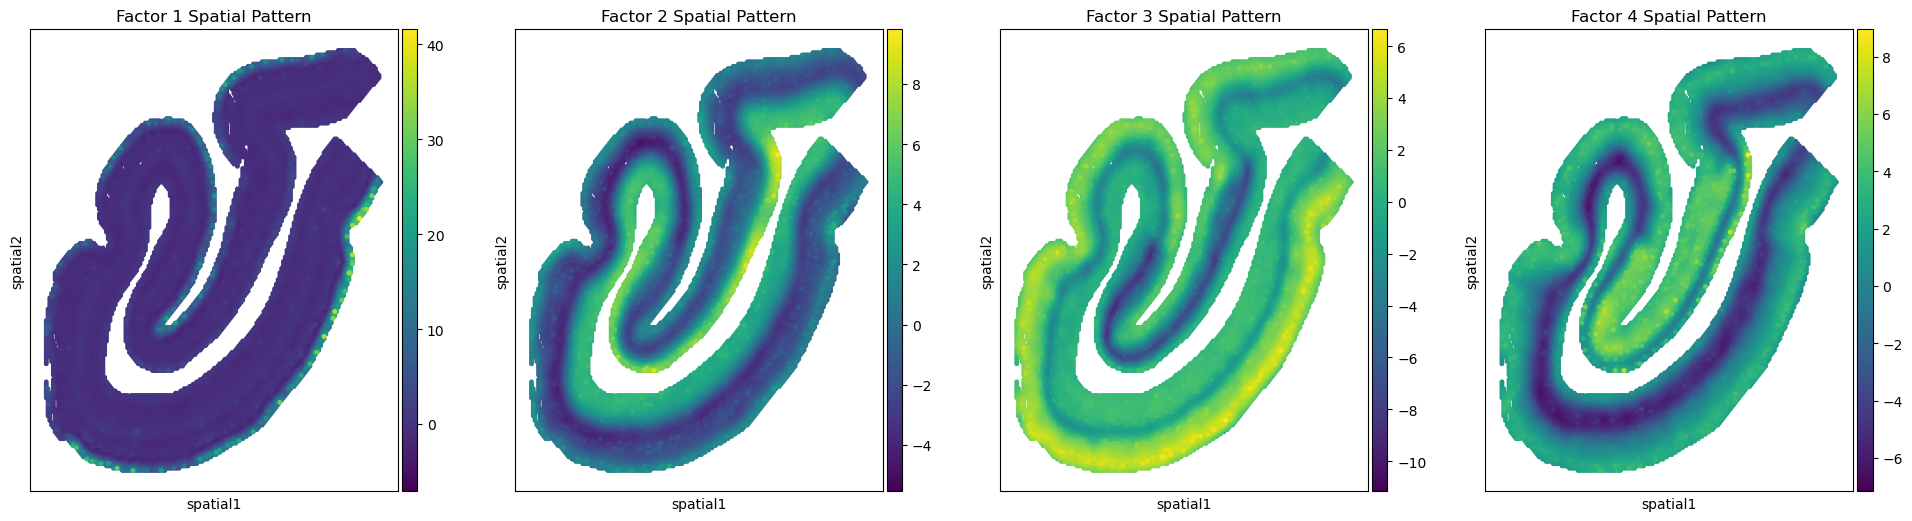

In [30]:
#plot spatial distribution of each factor
fig, ax = plt.subplots(1,4, figsize=(24, 6))
for factor_idx in range(1,5):
    sc.pl.embedding(
        combined_adata,
        basis='spatial',
        color=f'Factor{factor_idx}_model3',
        size=50,
        color_map='viridis',
        show=False,
        ax=ax[factor_idx-1]
    )
    ax[factor_idx-1].set_title(f'Factor {factor_idx} Spatial Pattern')
plt.show()

### Model 6

In [19]:
m = mofax.mofa_model("ST_model6.hdf5")

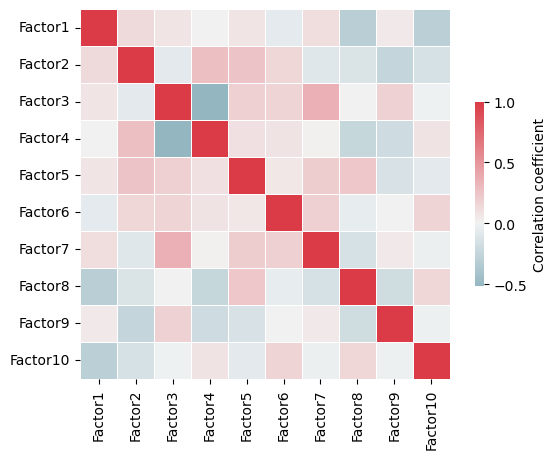

In [20]:
mofax.plot_factors_correlation(m);

In [21]:
factor_df=m.get_factors(df=True)

In [37]:
factor_df = factor_df.rename(columns={"Factor1": "Factor1_model6", "Factor2": "Factor2_model6","Factor3": "Factor3_model6", "Factor4": "Factor4_model6","Factor5": "Factor5_model6", "Factor6": "Factor6_model6","Factor7": "Factor7_model6", "Factor8": "Factor8_model6","Factor9": "Factor9_model6", "Factor10": "Factor10_model6", })

In [40]:
factor_df2 = factor_df.loc[:,["Factor5_model6","Factor6_model6", "Factor7_model6","Factor8_model6","Factor9_model6", "Factor10_model6"]]

In [41]:
combined_adata.obs = combined_adata.obs.join(factor_df2)

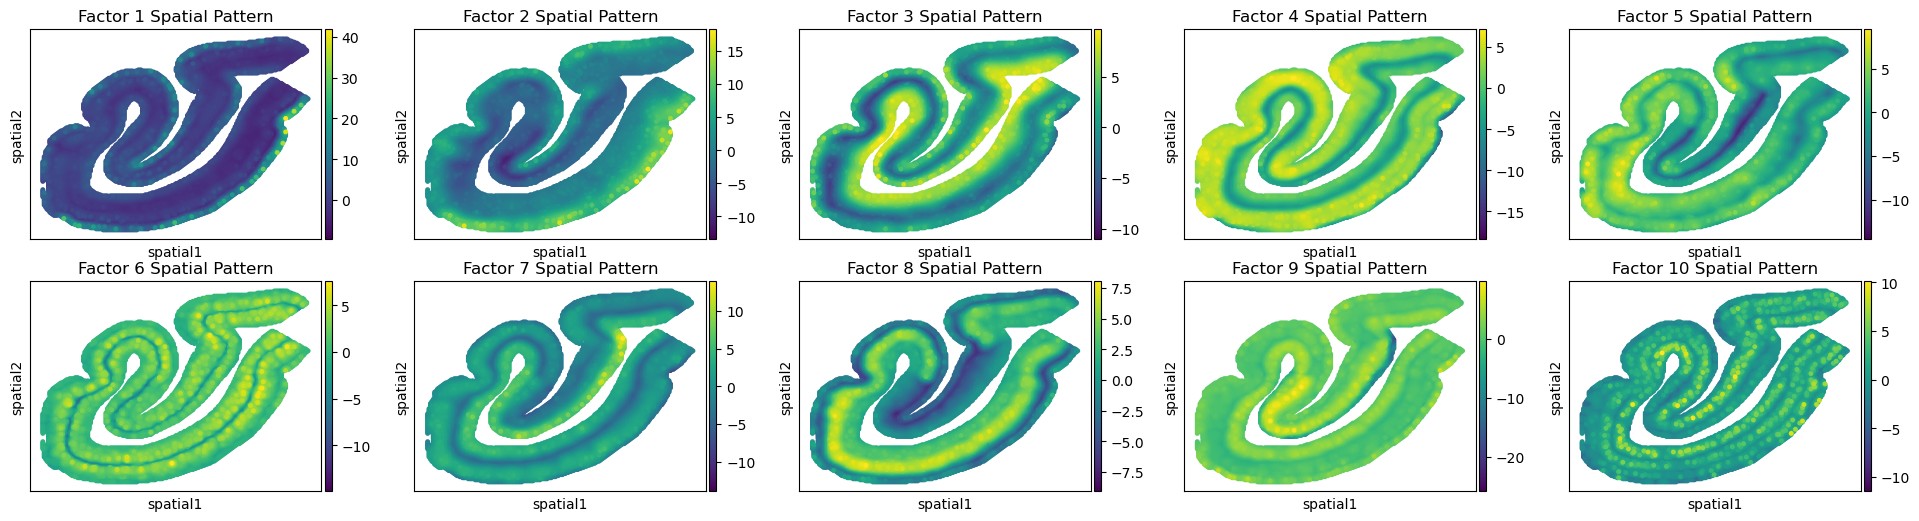

In [45]:
#plot spatial distribution of each factor
fig, ax = plt.subplots(2,5, figsize=(24, 6))
for factor_idx in range(1,11):
    sc.pl.embedding(
        combined_adata,
        basis='spatial',
        color=f'Factor{factor_idx}_model6',
        size=50,
        color_map='viridis',
        show=False,
        ax=ax[(factor_idx-1)//5,(factor_idx-1)%5]
    )
    ax[(factor_idx-1)//5, (factor_idx-1)%5].set_title(f'Factor {factor_idx} Spatial Pattern')
plt.show()

## Sanity check

In [23]:
#after ent.set_data_from_anndata(combined_adata, features_subset="highly_variable")
#check that the model is fine
print("Dimensions:", ent.dimensionalities)
print("Number of groups (G):", ent.dimensionalities.get("G"))
print("Number of samples per group (N):", ent.dimensionalities.get("N"))
print("Samples names in MOFA:", len(ent.data_opts.get("samples_names")[0]))
print("Groups in MOFA:", ent.data_opts.get("groups_names"))
print("Number of features (D):", ent.dimensionalities.get("D"))
print("Number of views (M):", ent.dimensionalities.get("M"))

Dimensions: {'C': 2, 'M': 1, 'G': 1, 'N': 19814, 'D': [2000], 'K': 4}
Number of groups (G): 1
Number of samples per group (N): 19814
Samples names in MOFA: 19814
Groups in MOFA: ['group1']
Number of features (D): [2000]
Number of views (M): 1
